# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Christian Santos`  
**SFU ID:** `cjs30`  
**Date:** `2026-07-01`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [2]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)

Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [3]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [4]:
# Missing values
df_ab.isnull().sum()


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


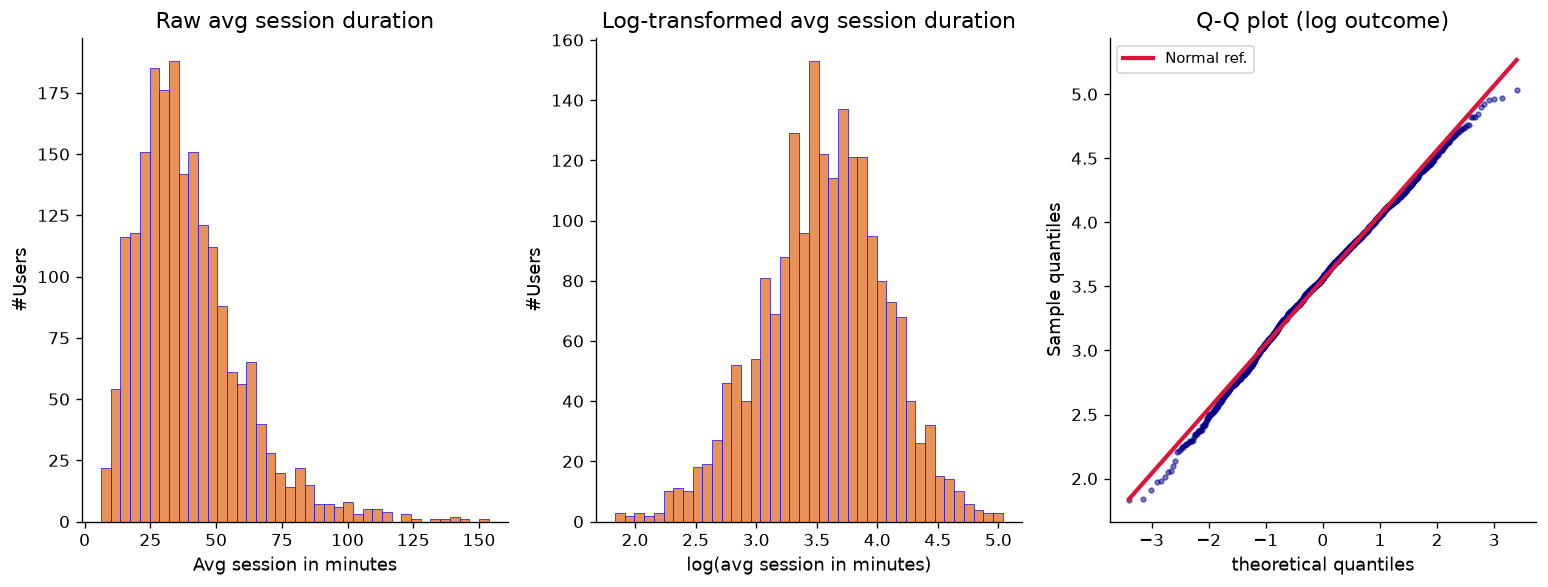

Skewness - raw outcome: 1.3768
Skewness - log outcome: -0.2135
R² of Q-Q fit: 0.9969


In [5]:
# BEGIN
#     Load target outcome variable

#     // 1. Normality & Transformation Visualizations
#     Initialize three-panel visual layout
    
#     Draw histogram of raw outcome distribution
#     Transform outcome variable using natural logarithm
#     Draw histogram of log-transformed outcome distribution
#     Draw Q-Q plot comparing log-transformed distribution to a normal distribution
    
#     Render visualizations

#     // 2. Statistical Diagnostics
#     Compute and output skewness for both raw and log-transformed distributions
# END

y_raw = df_ab['avg_whiteboard_session_duration_min']
y_log = np.log(y_raw)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

#raw data frame
axes[0].hist(y_raw, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4)
axes[0].set_title('Raw avg session duration')
axes[0].set_xlabel('Avg session in minutes')
axes[0].set_ylabel('#Users')

#log transformed
axes[1].hist(y_log, bins=40, color=ACCENT, edgecolor='blue', linewidth=0.4)
axes[1].set_title('Log-transformed avg session duration')
axes[1].set_xlabel('log(avg session in minutes)')
axes[1].set_ylabel('#Users')

#Q-Q plot
# osm = order statistic medians
# osr = ordered sample ranks
# slope and intercept = reference line
# r = correlation coefficient between osm and osr
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist='norm')
axes[2].scatter(osm, osr, color='darkblue', s=8, alpha=0.5)
axes[2].plot(osm, slope * np.array(osm) + intercept, color='crimson', lw=2.5, label='Normal ref.')
axes[2].set_title('Q-Q plot (log outcome)')
axes[2].set_xlabel('theoretical quantiles')
axes[2].set_ylabel('Sample quantiles')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

skew_raw = float(y_raw.skew())
skew_log = float(y_log.skew())
print(f"Skewness - raw outcome: {skew_raw:.4f}")
print(f"Skewness - log outcome: {skew_log:.4f}")
print(f"R² of Q-Q fit: {r**2:.4f}")

**✏️ Your interpretation (A1.1):**

*Is the log-transformed outcome more normally distributed?*
- The log-transformed outcome is more normally distributed.

*How does the Q-Q plot support your conclusion?*
- The log-transformed data is very close to the Q-Q plot line and has a 0.9969 Q-Q fit.

*Will you use the raw or log outcome in your model?*
- I will use the log outcome in my model.

#### A1.2 — Examine the confounders

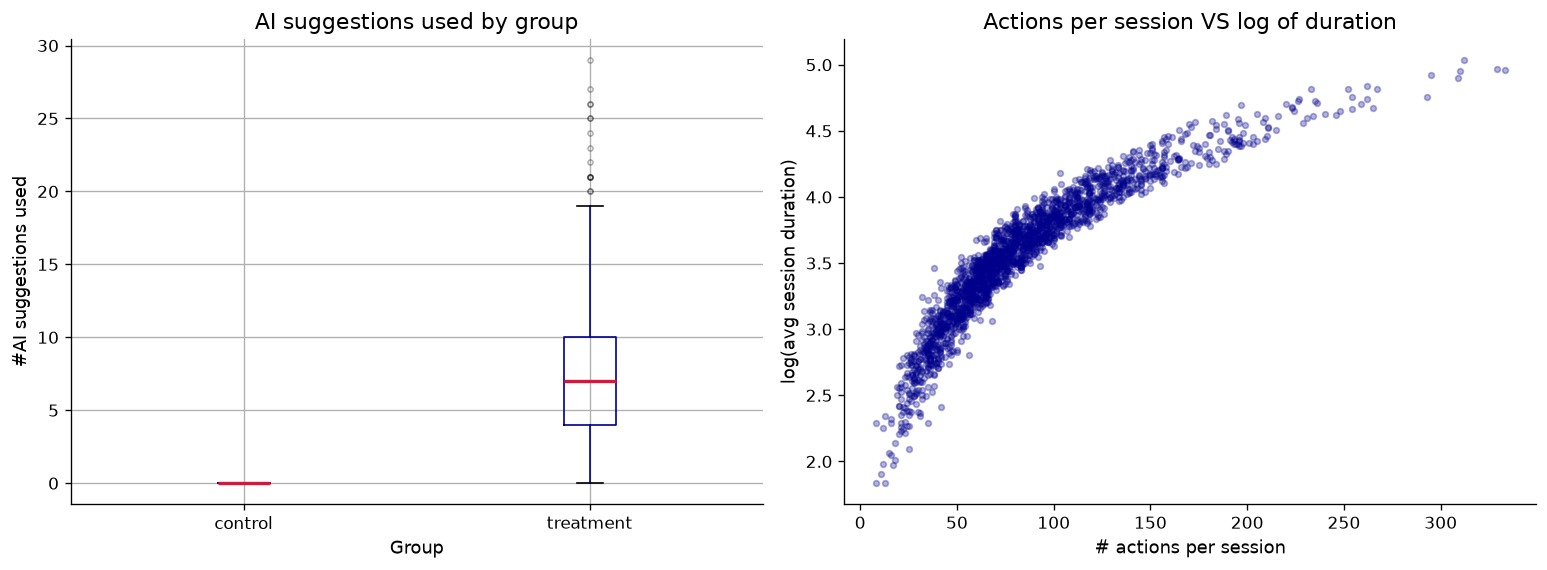

Pearson r (whiteboard_actions_per_session vs log_duration): 0.9136

Descriptive stats for ai_suggestions_used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [6]:
# // Define the analytical pipeline
# BEGIN
#     Load AB testing dataset

#     // 1. Visual Exploratory Data Analysis
#     Initialize side-by-side visualization layouts
    
#     Draw boxplot comparison of AI suggestion usage across experimental groups
#     Draw scatter plot comparing whiteboard activity density against session durations
    
#     Optimize layout and display visualizations

#     // 2. Statistical Analysis
#     Calculate and print the correlation between whiteboard activity and session duration
#     Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
# END

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#left boxplot of ai suggestions
df_ab.boxplot(column='ai_suggestions_used', by='ab_group', ax=axes[0],
              boxprops=dict(color='darkblue'), medianprops=dict(color='crimson', lw=2),
              whiskerprops=dict(color='darkblue'), capprops=dict(color='black'),
              flierprops=dict(marker='o', color='blue', alpha=0.3, markersize=3)
              )
axes[0].set_title('AI suggestions used by exp group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('#AI suggestions used')
plt.sca(axes[0])
plt.title('AI suggestions used by group')
plt.suptitle('')

# right side scatter plot of white_board actions per session vs log(duration)
log_dur = np.log(df_ab['avg_whiteboard_session_duration_min'])
axes[1].scatter(df_ab['whiteboard_actions_per_session'], log_dur, color='darkblue',
                alpha=0.3, s=12
                )
axes[1].set_title('Actions per session VS log of duration')
axes[1].set_xlabel('# actions per session')
axes[1].set_ylabel('log(avg session duration)')

plt.tight_layout()
plt.show()

corr_actions = df_ab['whiteboard_actions_per_session'].corr(log_dur)
print(f"Pearson r (whiteboard_actions_per_session vs log_duration): {corr_actions:.4f}")

print("\nDescriptive stats for ai_suggestions_used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))

**✏️ Your interpretation (A1.2):**

*What do you notice about `ai_suggestions_used` across the two groups?*
- The control group did not use AI suggestions at all because they do not have access to AI features. The treatment group used AI.

*What does the correlation between `whiteboard_actions_per_session` and the outcome suggest?*
- It suggests that users with AI have more whiteboard actions. Most the the dots are skewed towards the bottom.

*Why should neither be included in your model?*
- We need to exclude both because the treatment group has more of the ai_suggestions_used and more of the whiteboard_actions_per_session. Those who use whiteboard_actions_per_sessions longer will have a larger number of actions per session.

#### A1.3 — Predictor distributions and relationships with outcome

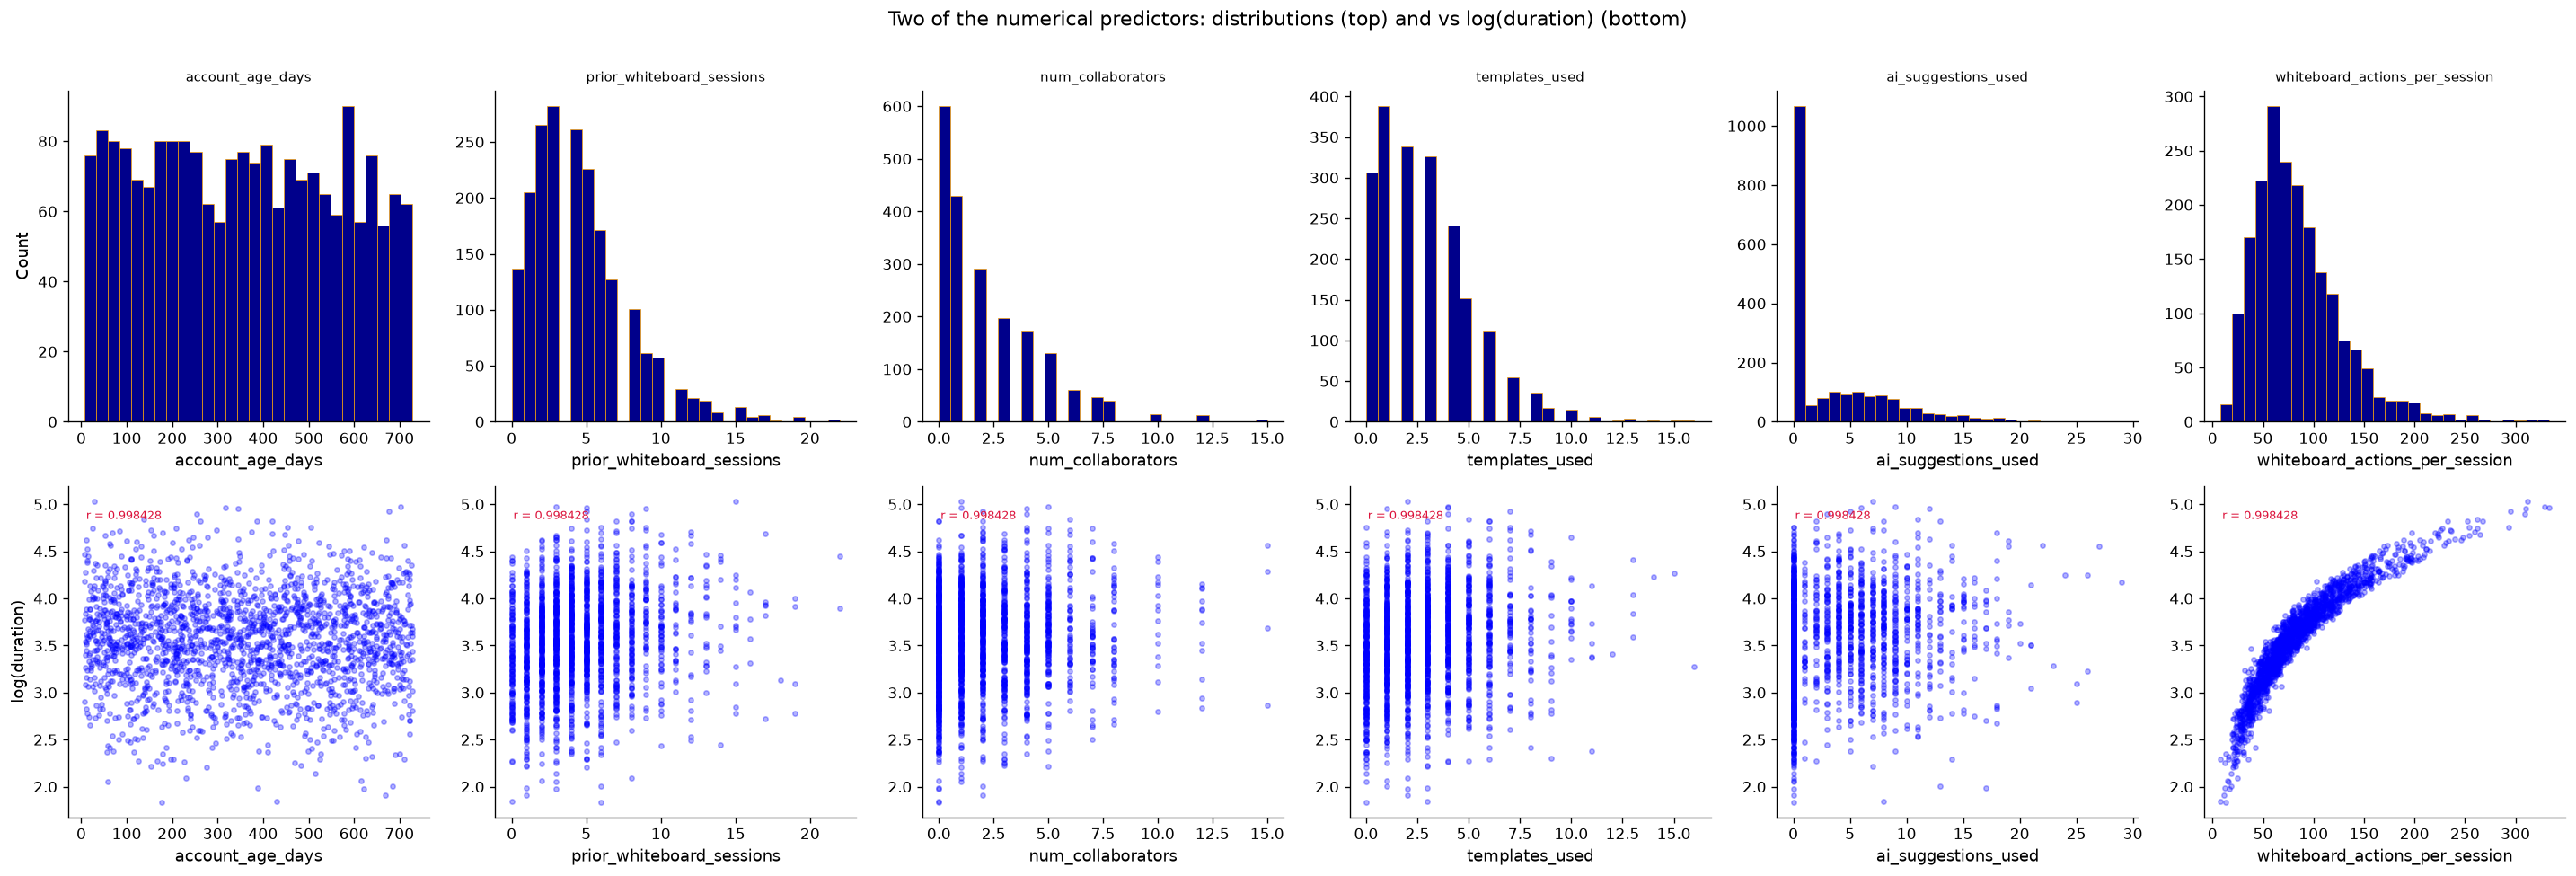

In [7]:
# BEGIN
#     Define list of numerical predictor variables
#     Compute log-transformed outcome variable

#     Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

#     FOR each predictor variable:
#         // Top row: Univariate Analysis
#         Draw histogram to show distribution of the predictor
        
#         // Bottom row: Bivariate Analysis
#         Draw scatter plot comparing predictor against log-transformed outcome
#         Calculate correlation coefficient between predictor and log-transformed outcome
#         Annotate plot with correlation coefficient
#     END FOR

#     Add global title and render layout
# END

num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators',
    'templates_used',
    'ai_suggestions_used',
    'whiteboard_actions_per_session'
]

n = len(num_predictors)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle('Two of the numerical predictors: distributions (top) and vs log(duration) (bottom)',
            fontsize=13, y=1.01)

for j, col in enumerate(num_predictors):
    # top tow: histogram
    axes[0, j].hist(df_ab[col], bins=28, color='darkblue', edgecolor='orange', lw=0.4)
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xlabel(col)
    axes[0, j].set_ylabel('Count' if j == 0 else '')
    
    # bottom row: scatterplot
    axes[1, j].scatter(df_ab[col], log_dur, color='blue', alpha=0.3, s=10)
    axes[1, j].set_xlabel(col)
    axes[1, j].set_ylabel('log(duration)' if j == 0 else '')
    axes[1, j].annotate(f'r = {r:2f}', xy=(0.05, 0.9),
                        xycoords='axes fraction', fontsize=8, color='crimson')
    
plt.tight_layout()
plt.show()

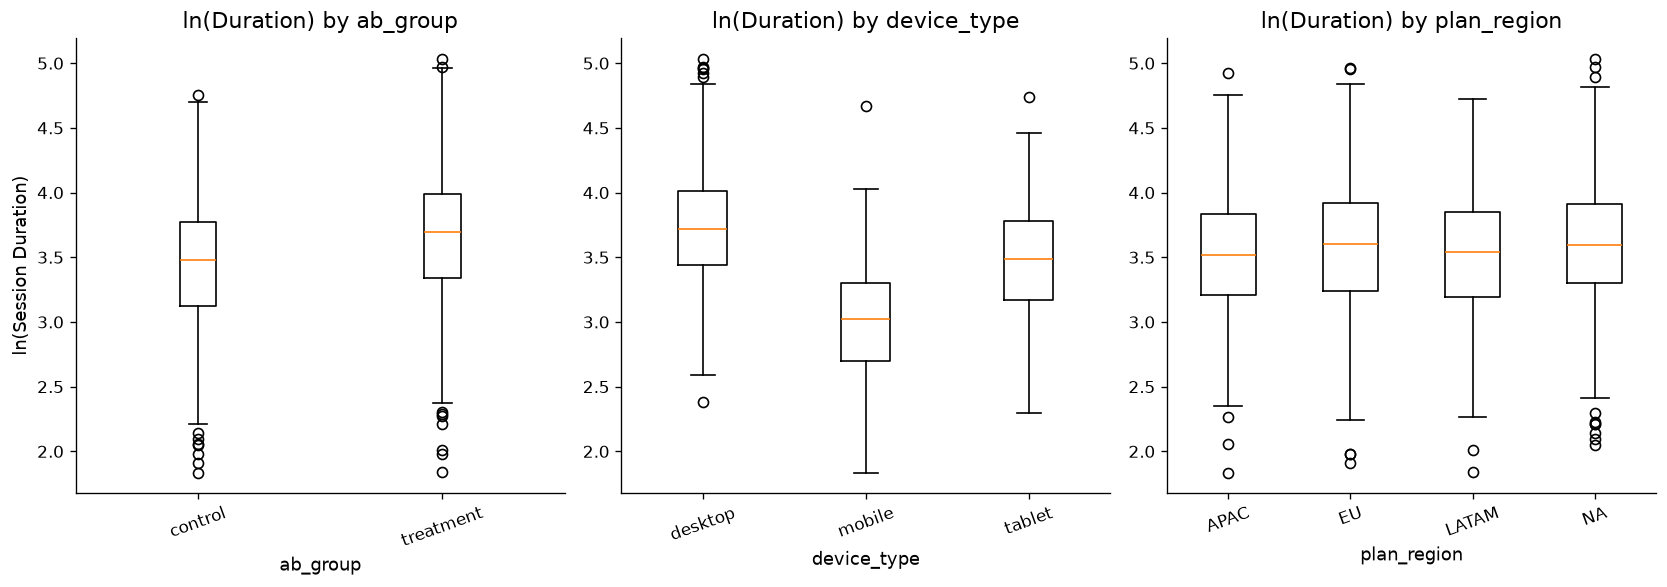

In [8]:
# BEGIN
#     Define list of categorical predictor variables
#     Initialize visual grid layout (1 row by N columns, where N is the number of categories)

#     FOR each categorical variable:
#         Retrieve unique category levels
        
#         Group log-transformed outcome values by category levels
        
#         Draw boxplots of log-transformed outcome grouped by category level
#         Rotate category axis labels for readability
        
#         Label axis and set titles
#     END FOR

#     Render layout
# END

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
df_ab_cat = pd.read_csv('phigma_ab_study.csv', keep_default_na=False, na_values=[''])
df_ab_cat['log_duration'] = np.log(df_ab_cat['avg_whiteboard_session_duration_min'])

cat_preds = ['ab_group', 'device_type', 'plan_region']
fig, axes = plt.subplots(1, len(cat_preds), figsize=(14, 5))

for i, col in enumerate(cat_preds):
    categories = sorted(df_ab_cat[col].dropna().unique())

    data = [df_ab_cat.loc[df_ab_cat[col] == c, 'log_duration'].values for c in categories]

    axes[i].boxplot(data, tick_labels=categories)
    axes[i].set_title(f'ln(Duration) by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ln(Session Duration)' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
#END[Sonnet]

**✏️ Your interpretation (A1.3):**

*Which predictors look most promising?*
- prior_whiteboard_sessions, num_collaborators, and templates_used look promising because they correlate with ln(Session Duration).

*Are any right-skewed and worth log-transforming before use as predictors?*
- account_age_days, prior_whiteboard_sessions, num_collaborators, and templates_used are right skewed, the log doe snot provide additional information that the histogram already shows.

*Which two features are you excluding and why?*
- I am excluding acount_age_days because the duration is the same throughout the data and feature_tour_completed because there are only 2 possible values.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [9]:
# BEGIN
#     Load baseline dataset

#     // 1. Encode Categorical Variables
#     Convert experimental group ('ab_group') into a binary integer indicator
#     Generate dummy indicators (one-hot encoding) for device types, omitting the first category
#     Generate dummy indicators (one-hot encoding) for regions, omitting the first category

#     // 2. Perform Optional Transformations
#     Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

#     // 3. Assemble Modeling Dataset
#     Merge numerical characteristics, binary groups, and dummy indicators into matrix X
#     Set target vector y as the log-transformed outcome variable

#     // 4. Quality Control
#     Verify that there are no missing (null) values in feature matrix X
#     Inspect matrix dimensions and print a preview of the processed data
# END

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
df_model = pd.read_csv('phigma_ab_study.csv', keep_default_na=False, na_values=[''])

df_model['ab_group_enc'] = (df_model['ab_group'] == 'treatment').astype(int)

device_dummies = pd.get_dummies(df_model['device_type'], prefix='device',
                                drop_first=True).astype(int)

region_dummies = pd.get_dummies(df_model['plan_region'], prefix='region',
                                drop_first=True).astype(int)

df_model['log_prior_sessions']     = np.log1p(df_model['prior_whiteboard_sessions'])
df_model['log_num_collaborators']  = np.log1p(df_model['num_collaborators'])
df_model['log_templates_used']     = np.log1p(df_model['templates_used'])
df_model['log_ai_suggestions_used'] = np.log1p(df_model['ai_suggestions_used'])

X = pd.concat([
    df_model[['ab_group_enc', 'log_prior_sessions',
              'log_num_collaborators', 'log_templates_used',
              'log_ai_suggestions_used']],
    device_dummies,
    region_dummies,
], axis=1).astype(float)

y = np.log(df_model['avg_whiteboard_session_duration_min'])

print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")
X.head(3)
# END[Sonnet]

Missing values in X: 0
Feature matrix shape: (2000, 10)

Features:
['ab_group_enc', 'log_prior_sessions', 'log_num_collaborators', 'log_templates_used', 'log_ai_suggestions_used', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM', 'region_NA']


,ab_group_enc,log_prior_sessions,log_num_collaborators,log_templates_used,log_ai_suggestions_used,device_mobile,device_tablet,region_EU,region_LATAM,region_NA
0,0.0,1.609438,1.386294,0.000000,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,2.302585,0.693147,0.693147,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,2.397895,1.791759,0.693147,0.0,0.0,0.0,0.0,0.0,1.0


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

- ab_group_enc: This determines whether the user is in the treatment group or not and this is a boolean.
- log_pior_sessions: More experienced users tend to work longer per session. This one is also skewed and a log(x+1) is applied.
- log_num_collaborators: More collaborators did not change the duration. This one is also skewed and a log(x+1) is applied.
- log_templates_used: Use of templates might imply more serious design work. log(x+1) is applied.
- log_ai_suggestions_used: The more ai suggestion used will increase the duration of sessions. log(x+1) is applied.
- device_mobile and device_tablet: When the screens are small, it is harder to work, compared to desktops. This is one_hot encoded.
- region_EU, region_LATAM, and region_NA: Regional usage did not differ across different regions. This is also one hot encoded.

### A3 — OLS Regression


In [10]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.366
Model:                                             OLS   Adj. R-squared:                  0.363
Method:                                  Least Squares   F-statistic:                     114.8
Date:                                 Tue, 30 Jun 2026   Prob (F-statistic):          1.33e-188
Time:                                         19:21:11   Log-Likelihood:                -1015.9
No. Observations:                                 2000   AIC:                             2054.
Df Residuals:                                     1989   BIC:                             2115.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                              coef    st

#### A3.1 — Interpret the model

In [11]:
# BEGIN
#     Input trained OLS regression model
#     Input experimental dataframe

#     // 1. Evaluate Model Fit
#     Display model's R-squared value to assess variance explained

#     // 2. Analyze Treatment Effect
#     Extract coefficient and significance (p-value) for the A/B testing variable
#     Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
#     Display treatment effect size and statistical significance

#     // 3. Extract Significant Predictors
#     Filter all model coefficients where p-value < 0.05
#     FOR each significant variable:
#         Display variable name, its directional coefficient, and its p-value
#     END FOR
# END

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
# model fit
r2 = model_ols.rsquared
print(f"R² = {r2:.4f}  ({r2*100:.1f}% of variance in log(session duration) explained)")

# treatment effect
ab_coef = model_ols.params['ab_group_enc']
ab_pval  = model_ols.pvalues['ab_group_enc']

treatment_pct = (np.exp(ab_coef) - 1) * 100
mean_dur = df_model['avg_whiteboard_session_duration_min'].mean()
treatment_min = mean_dur * (np.exp(ab_coef) - 1)

print(f"\nTreatment effect (ab_group_enc):")
print(f"  Log-scale coefficient : {ab_coef:.4f}")
print(f"  P-value               : {ab_pval:.2e}")
print(f"  Percentage change     : {treatment_pct:+.1f}%")
print(f"  At mean duration ({mean_dur:.1f} min): approx. {treatment_min:+.1f} minutes")

# significant predictors
sig = model_ols.pvalues[model_ols.pvalues < 0.05].sort_values()
print(f"\nSignificant predictors (α = 0.05):")
for name, pval in sig.items():
    coef = model_ols.params[name]
    pct  = (np.exp(coef) - 1) * 100 if name != 'const' else float('nan')
    print(f"  {name:<30}  coef={coef:+.4f}  p={pval:.2e}  effect≈{pct:+.1f}%")
#END[Sonnet]

R² = 0.3659  (36.6% of variance in log(session duration) explained)

Treatment effect (ab_group_enc):
  Log-scale coefficient : 0.2171
  P-value               : 3.71e-06
  Percentage change     : +24.2%
  At mean duration (39.5 min): approx. +9.6 minutes

Significant predictors (α = 0.05):
  const                           coef=+3.2034  p=0.00e+00  effect≈+nan%
  device_mobile                   coef=-0.7231  p=2.72e-140  effect≈-51.5%
  device_tablet                   coef=-0.2549  p=1.99e-31  effect≈-22.5%
  log_prior_sessions              coef=+0.1405  p=5.00e-24  effect≈+15.1%
  log_num_collaborators           coef=+0.0888  p=2.44e-12  effect≈+9.3%
  log_templates_used              coef=+0.0791  p=1.63e-07  effect≈+8.2%
  ab_group_enc                    coef=+0.2171  p=3.71e-06  effect≈+24.2%
  region_NA                       coef=+0.0842  p=3.89e-04  effect≈+8.8%
  region_EU                       coef=+0.0758  p=1.93e-03  effect≈+7.9%


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*

The p value is less than the alpha of 0.05. This shows evidence against the null hypothesis. The R squared is not a great model fit as it is only 37%. The AI assistant significantly increased session duration, and this effect is both statistically and practically meaningful for user engagement. Device type is the strongest predictor, since mobile and tablet users experienced notably shorter sessions than desktop users, likely due to the smaller screens. More experienced users, as measured by their prior session history and template usage, also spent longer in sessions. Together, these factors explains meaningful patterns in user engagement, though unmeasured factors remain important for explaining session duration.

#### A3.2 — Regression diagnostics

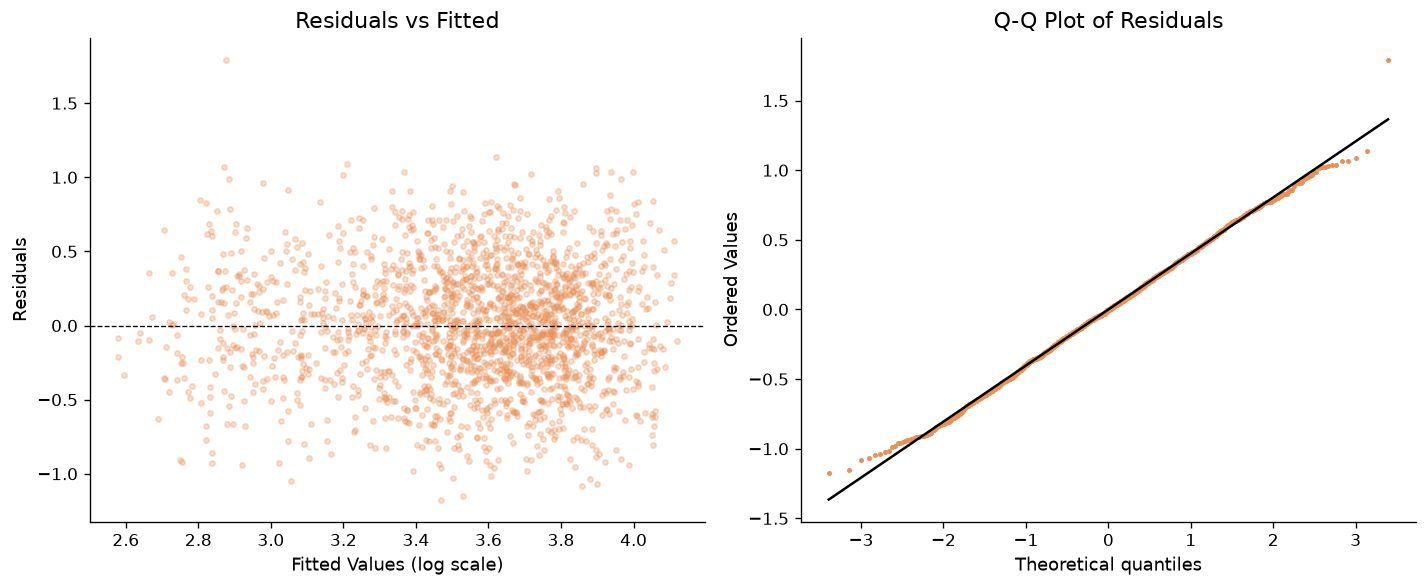

In [12]:
# BEGIN
#     Extract predictions and error terms (residuals) from regression model
#     Initialize a side-by-side diagnostic visualization layout

#     // Check for uniform variance (homoscedasticity)
#     Draw scatter plot of prediction values vs residuals
#     Overlay a horizontal zero-error baseline reference line
    
#     // Check for normality of errors
#     Draw a Q-Q plot of residuals against a normal theoretical distribution

#     Render diagnostic plots
# END

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
fitted    = model_ols.fittedvalues
residuals = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter plot of prediction values vs residuals
axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color=ACCENT)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Fitted Values (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q Plot of residuals
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
axes[1].get_lines()[0].set(color=ACCENT, markersize=2)
axes[1].get_lines()[1].set(color='black')

plt.tight_layout()
plt.show()
#END[Sonnet]

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero?*
- The residuals look ramdonly scattered around zero.

*Does the Q-Q plot suggest normally distributed errors?*
- Yes, the Q-Q plot shows that the points are mostly on the theoretical line.

*Note any patterns that concern you.*
- There are minor tails deviations in the Q-Q plot.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing?*
- I am tesing the interaction between AI treatment (ab_group) and user experience level (prior_whiteboard_sessions).

*Which two variables?*
- ab_group_enc and log_prior_sessions.

*What is your theoretical reason for expecting this interaction?*
- Newer users have more uncertainty about what to do next. AI suggestions would help them. However, experienced users already have their own workflows and may find AI suggestions less useful or even disruptive.

*Which group do you predict will benefit more from the AI assistant?*
- Less expereinced users will benefit more. The benefit of having AI is less for more experienced users.

In [13]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
interaction_col = pd.DataFrame({
    'ab_x_log_prior': X['ab_group_enc'] * X['log_prior_sessions']
})

X_interact      = pd.concat([X, interaction_col], axis=1)
X_interact_const = sm.add_constant(X_interact)
model_interact  = sm.OLS(y, X_interact_const).fit()

print(model_interact.summary())

ic = model_interact.params['ab_x_log_prior']
ip = model_interact.pvalues['ab_x_log_prior']
print(f"\nInteraction coefficient (ab_group x log_prior_sessions): {ic:.4f}, p = {ip:.4f}")
#END[Sonnet]

                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.367
Model:                                             OLS   Adj. R-squared:                  0.363
Method:                                  Least Squares   F-statistic:                     104.7
Date:                                 Tue, 30 Jun 2026   Prob (F-statistic):          3.69e-188
Time:                                         19:21:11   Log-Likelihood:                -1014.5
No. Observations:                                 2000   AIC:                             2053.
Df Residuals:                                     1988   BIC:                             2120.
Df Model:                                           11                                         
Covariance Type:                             nonrobust                                         
                              coef    st

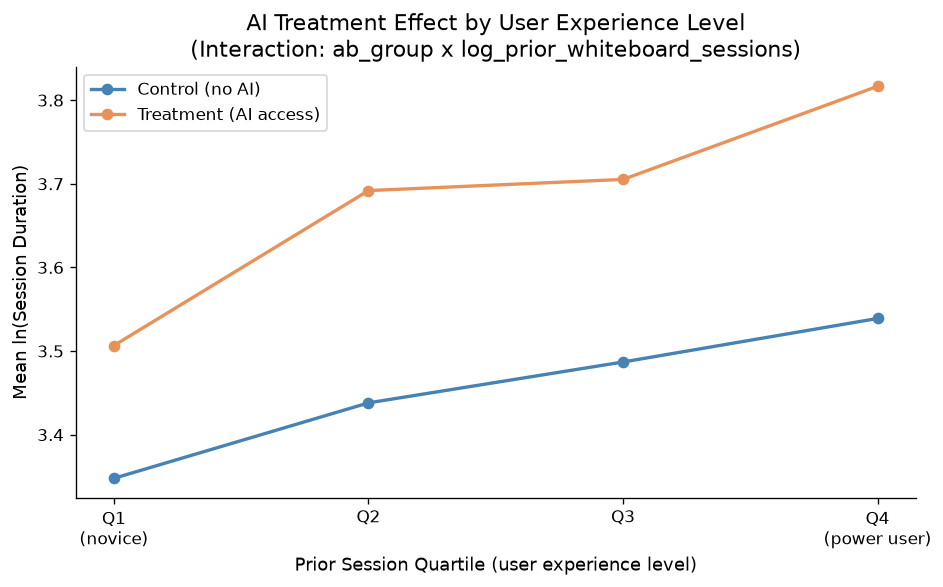

In [14]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
df_viz = df_model.copy()
df_viz['log_duration'] = y.values

df_viz['prior_q'] = pd.qcut(
    df_viz['prior_whiteboard_sessions'], q=4,
    labels=['Q1\n(novice)', 'Q2', 'Q3', 'Q4\n(power user)']
)

summary = (
    df_viz.groupby(['prior_q', 'ab_group'], observed=True)['log_duration']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for group, color, label in [
    ('control',   'steelblue', 'Control (no AI)'),
    ('treatment', ACCENT,      'Treatment (AI access)'),
]:
    sub = summary[summary['ab_group'] == group]
    ax.plot(
        sub['prior_q'].astype(str), sub['log_duration'],
        marker='o', color=color, label=label, lw=2
    )

ax.set_xlabel('Prior Session Quartile (user experience level)')
ax.set_ylabel('Mean ln(Session Duration)')
ax.set_title(
    'AI Treatment Effect by User Experience Level\n'
    '(Interaction: ab_group x log_prior_whiteboard_sessions)'
)
ax.legend()
plt.tight_layout()
plt.show()
#END[Sonnet]

**✏️ Your interpretation (A4):**

*Was your hypothesis supported?*
- No, the interactions coefeccient was not significant. This shows that experienced users use AI for longer sessions than novices.

*What does the interaction coefficient tell you about which users benefit most from the AI assistant?*
- The coeficient direction was positive. This means as expereince increases the use of AI increases. I thought that AI is less helpful for experienced users.

*What does this imply for how Phigma should roll out the feature?*
- The benefit of AI seems to be the same regardless of which group so they can release the feature to everyone.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [15]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)

Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [16]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [17]:
# YOUR CODE HERE

# 1. Parse dates
df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] > 0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d'],
    0.0
)

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True).astype(int)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True).astype(int)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal):
df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']
base_features = [
    'num_sessions_30d',         # total engagement depth
    'total_time_min_30d',       # total time invested
    'projects_created_30d',     # creative output
    'exports_30d',              # file export behavior (actionable output)
    'collaborators_invited_30d', # network effects
    'support_tickets_30d',       # friction / active exploration
    'used_premium_feature_preview',  # explicit upgrade intent
    'ai_assistant_sessions_30d',     # AI tool engagement
    'days_to_first_session',    # onboarding speed
    'avg_session_duration_min', # session depth per visit
    'is_weekend_signup',        # signup context
    'country_tier_enc',         # market purchasing power
]

X_sub = pd.concat(
    [df_sub[base_features], device_dummies2, referral_dummies],
    axis=1
).astype(float)

y_sub = df_sub['subscribed']

# Confirm
print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)


Any inf: False
Any NaN: False
Feature matrix shape: (3000, 17)


,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1.0,96.0,1.0,0.0,0.0,0.0,1.0,6.0,5.0,96.0000,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,15.0,267.0,8.0,1.0,5.0,0.0,0.0,0.0,0.0,17.8000,0.0,2.0,0.0,1.0,0.0,0.0,1.0
2,16.0,263.0,0.0,0.0,3.0,3.0,1.0,4.0,14.0,16.4375,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription?*
- days_to_first_session: The lower the value, the sooner the user uses the app. This might mean that the user is keen to use it.
- avg_session_duration_min: The longer the sessions, the more interested the user is and the more likely the user will pay for continued access.
- is_weekend_signup: This might indicate if the user is using it for work or for hobby / casual.
- country_tier_enc: The richer the country, the more its citizens can afford subscriptions.
- device_mobile and device_tablet: This might indicate that smaller devices are for users that are not as serious as desktop users.
- ref_paid_ad, ref_referral, and ref_social: If a user is referred then they might be more interested in a dubscription.

*Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*
- I set the result to 0 when the user had zero sessions.

### B2 — EDA for Subscription


In [18]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


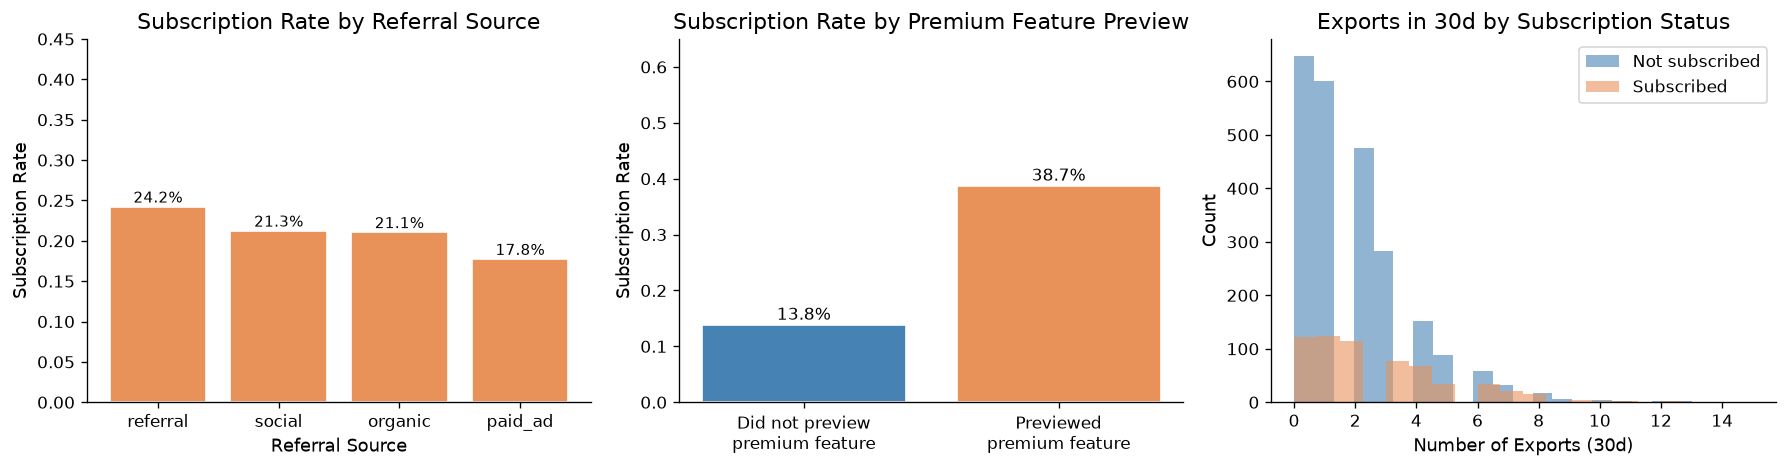

In [19]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
# Plot 1 — YOUR CODE
ref_rate = (
    df_sub.groupby('referral_source')['subscribed'].mean()
    .sort_values(ascending=False)
)
axes[0].bar(ref_rate.index, ref_rate.values, color=ACCENT, edgecolor='white')
axes[0].set_title('Subscription Rate by Referral Source')
axes[0].set_xlabel('Referral Source')
axes[0].set_ylabel('Subscription Rate')
axes[0].set_ylim(0, 0.45)
for i, v in enumerate(ref_rate.values):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

# Plot 2 — YOUR CODE
prem_rate = df_sub.groupby('used_premium_feature_preview')['subscribed'].mean()
axes[1].bar(
    ['Did not preview\npremium feature', 'Previewed\npremium feature'],
    prem_rate.values,
    color=['steelblue', ACCENT], edgecolor='white'
)
axes[1].set_title('Subscription Rate by Premium Feature Preview')
axes[1].set_ylabel('Subscription Rate')
axes[1].set_ylim(0, 0.65)
for i, v in enumerate(prem_rate.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Plot 3 — YOUR CODE
df_sub[df_sub['subscribed'] == 0]['exports_30d'].plot.hist(
    ax=axes[2], bins=20, alpha=0.6, color='steelblue', label='Not subscribed'
)
df_sub[df_sub['subscribed'] == 1]['exports_30d'].plot.hist(
    ax=axes[2], bins=20, alpha=0.6, color=ACCENT, label='Subscribed'
)
axes[2].set_title('Exports in 30d by Subscription Status')
axes[2].set_xlabel('Number of Exports (30d)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()
#END[Sonnet]

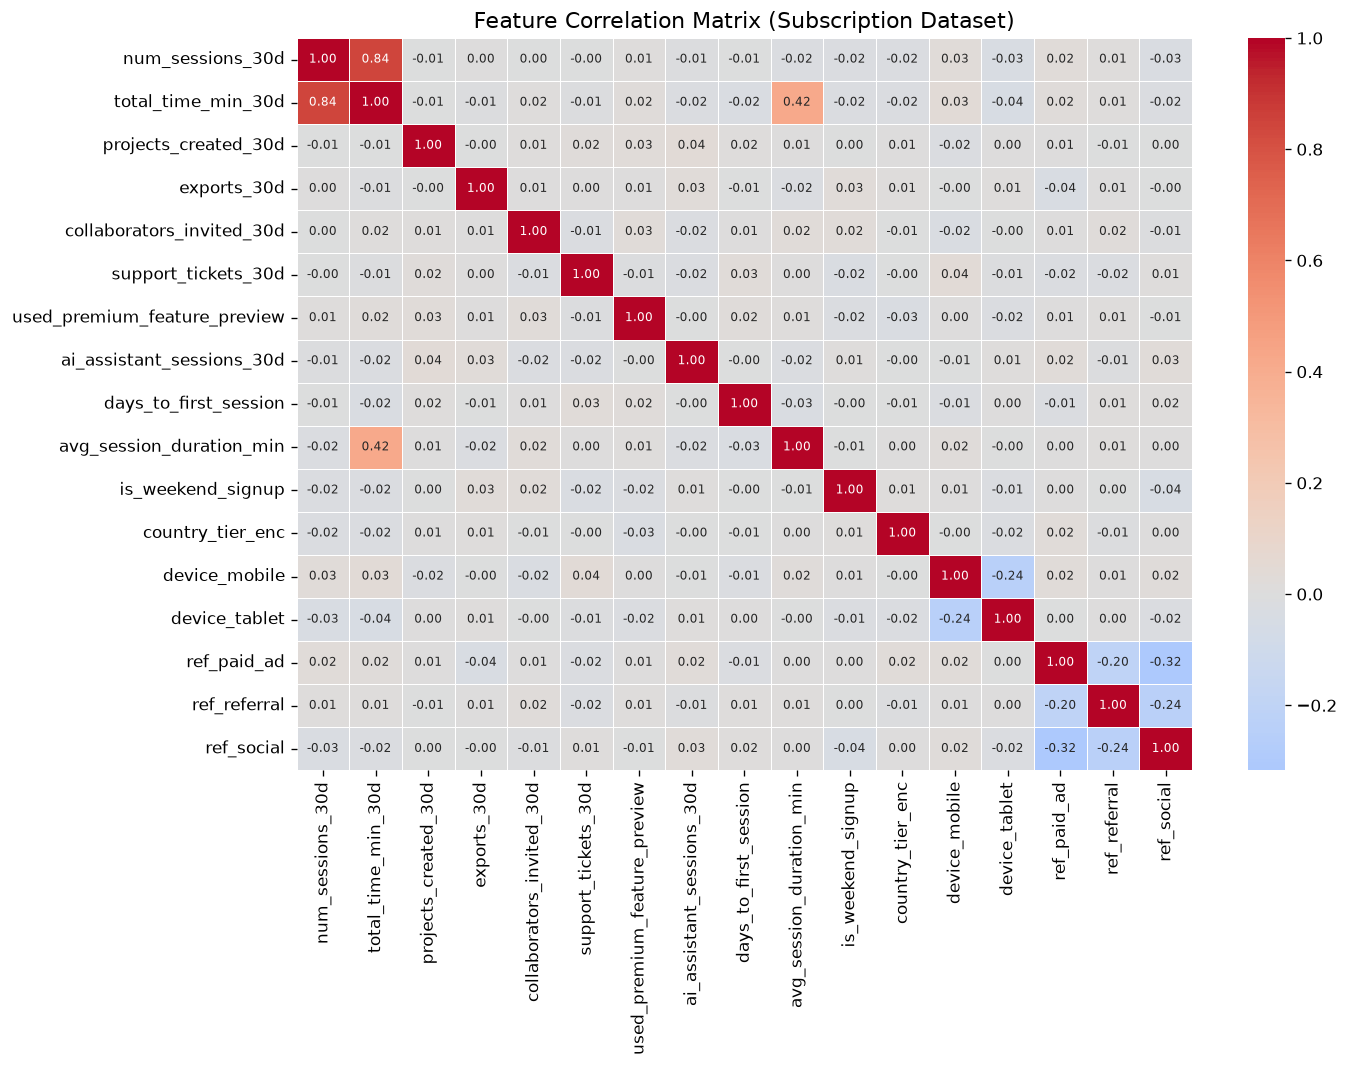

In [20]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
corr = X_sub[numeric_features].corr()
# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    ax=ax, linewidths=0.5,
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix (Subscription Dataset)')
plt.tight_layout()
plt.show()
#END[Sonnet]

**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA?*
- Premium feature preview and referral source are the most strongly associated with subscription in the EDA.

*Are any findings counterintuitive?*
- The subscription rate by referral source plot have bars that have similar values. I thought that referral, social, andn paid_ad would be greater than organic but it is not the case.

*Note any features that appear highly correlated with each other — does this concern you?*
- The num_sessions_30d and total_time_min_30d are highly correlated because the more sessions there are, the longer the total time.

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [21]:
# YOUR CODE HERE
X_const_sub = sm.add_constant(X_sub)
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.1392
Time:                        19:21:14   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [22]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
odds_ratios = np.exp(model_logit.params)
conf_int    = np.exp(model_logit.conf_int())
conf_int.columns = ['OR_lower', 'OR_upper']
pvals       = model_logit.pvalues
# Combine into a readable table and display
# Filter to significant only: p < 0.05

or_table = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'CI Lower':   conf_int['OR_lower'],
    'CI Upper':   conf_int['OR_upper'],
    'p-value':    pvals,
})

sig_or = (
    or_table[or_table['p-value'] < 0.05]
    .drop('const', errors='ignore')
    .sort_values('Odds Ratio', ascending=False)
)

print("Significant Predictors — Odds Ratios (p < 0.05):")
print(sig_or.round(4).to_string())
#END[Sonnet]

Significant Predictors — Odds Ratios (p < 0.05):
                              Odds Ratio  CI Lower  CI Upper  p-value
used_premium_feature_preview      4.3470    3.5745    5.2864   0.0000
exports_30d                       1.2142    1.1633    1.2674   0.0000
support_tickets_30d               1.1673    1.0727    1.2702   0.0003
collaborators_invited_30d         1.0632    1.0178    1.1106   0.0059
avg_session_duration_min          1.0315    1.0112    1.0523   0.0023
days_to_first_session             0.9114    0.8872    0.9364   0.0000
country_tier_enc                  0.7001    0.6158    0.7959   0.0000


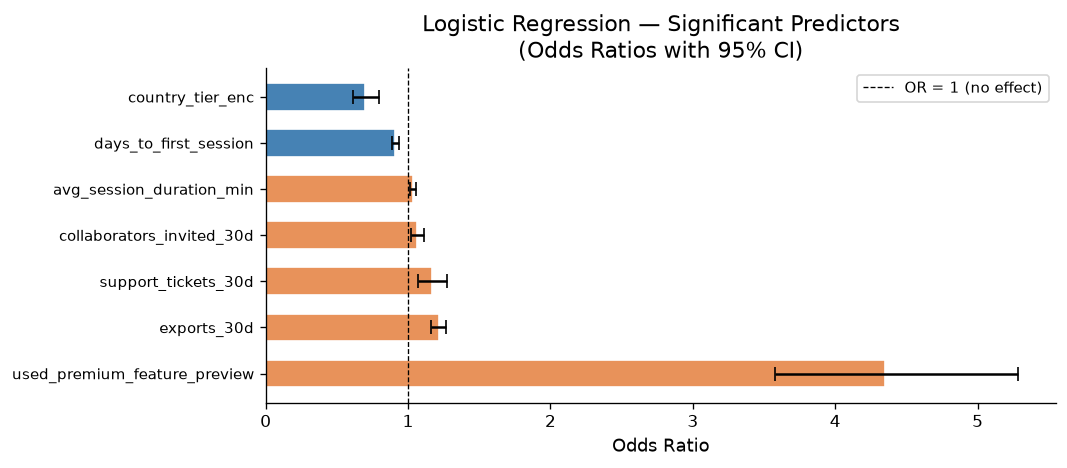

In [23]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
fig, ax = plt.subplots(figsize=(9, max(4, len(sig_or) * 0.55)))

bar_colors = [ACCENT if v > 1 else 'steelblue' for v in sig_or['Odds Ratio']]
y_pos = range(len(sig_or))

ax.barh(list(y_pos), sig_or['Odds Ratio'], color=bar_colors,
        edgecolor='white', height=0.6)
ax.errorbar(
    sig_or['Odds Ratio'], list(y_pos),
    xerr=[
        sig_or['Odds Ratio'] - sig_or['CI Lower'],
        sig_or['CI Upper']   - sig_or['Odds Ratio'],
    ],
    fmt='none', color='black', capsize=4, lw=1.5
)
ax.axvline(1.0, color='black', linestyle='--', lw=0.8, label='OR = 1 (no effect)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(sig_or.index, fontsize=9)
ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression — Significant Predictors\n(Odds Ratios with 95% CI)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
#END[Sonnet]

**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe...").*
- users_premium_feature_preview: This is the higest odds ratio which is a clear predictor that users will subscribe when they have seen the preview.
- days_to_first_session: The odds ratio is slightly less than 1. The sooner users start after signing up the less likely they become subscribers.
- avg_session_duration_min: The longer the user sessions is the more likely the user will become a subscriber. This is very close to 1 which means that the ffect is very little.

*Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*
- The users_premium_feature_preview suspected already that it will be correlated to subscription, but it was not expected to be this much compared to the other odds ratios.

### B4 — Logistic Regression with sklearn (Predictive)


In [24]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")

Train: (2400, 17)  |  Test: (600, 17)
Train positive rate: 0.208  |  Test positive rate: 0.208


In [25]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]

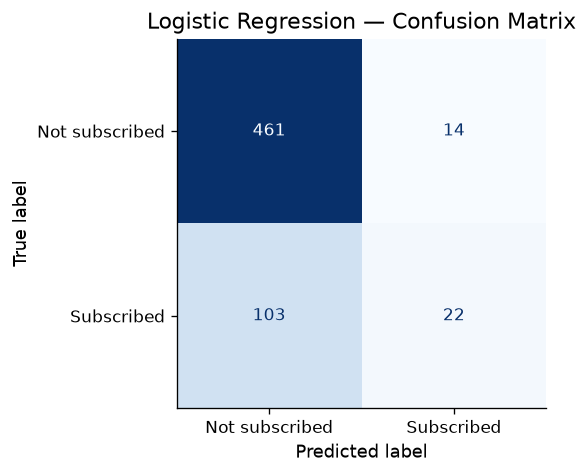

In [26]:
# YOUR CODE HERE
# Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [27]:
# YOUR CODE HERE
# Classification report
print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.61      0.18      0.27       125

      accuracy                           0.81       600
     macro avg       0.71      0.57      0.58       600
  weighted avg       0.77      0.81      0.76       600

ROC-AUC: 0.7374


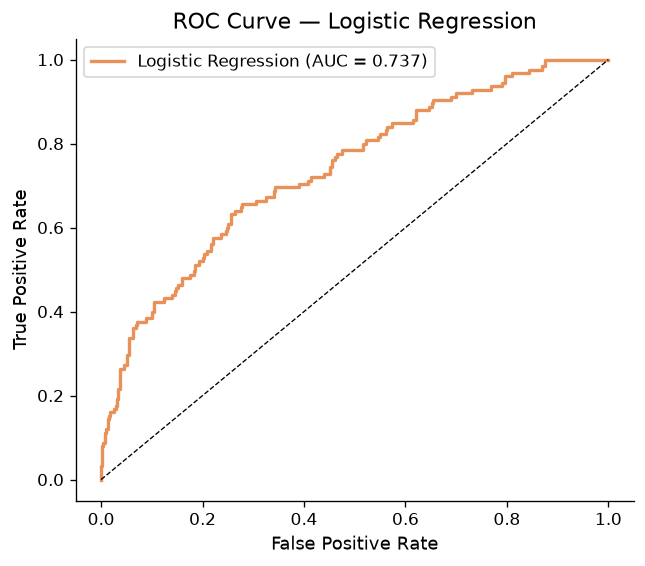

In [28]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()

**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why?*
- ROC-AUC is the most informative single metric because it measures how well the model ranks subscribers above non subscribers across all possible thresholds, not just the default 50% cutoff. Accuracy is misleading here. A model that always predicts not subscribed would score high accuracy while being completely useless.

*Interpret the confusion matrix: how many false negatives does the model produce?*
- The confusion matrix shows 14 false negatives.

*From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*
- Each false negative is a missed revenue opportunity. A user who was ready to subscribe but received no special offer (no email) because the model failed to flag them. The default 50% threshold is too strict. Lowering it would catch more potential subscribers at the cost of sending more messages to non converters, which is usually the right trade off.

---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `Random Forest`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data?*
- A random set of rows and a random set of features are used to make a decision tree that makes a prediciton. This is repeated for many random sets of rows and columns. The final answer is determined form the most popular prediction across all trees.

*What does it optimize?*
- It optimizes by grouping subscribers together and non subscribers together. It also optimizes by choosing different sets. This emphasises the difference between subscribers and non subscribers.

*How is it structurally different from logistic regression?*
- Logistic regression draws a single straight line. Random Forest draws many complex, non-linear boundaries.

*Why might it perform differently on this particular dataset given what you know about the features?*
- With random forests working on small subsets at a time it fails to see the big picture. However, logistic regression aims to find a paramteric mathematical relationship between features as a whole. This particilar dataset seems to have features that are mostly linear in relation to subscription.

### C2 — Fit and Evaluate


In [29]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)
y_prob_rf  = clf_rf.predict_proba(X_test)[:, 1]   # probability of class 1

print("Random Forest fitted successfully.")
print(f"Number of trees: {clf_rf.n_estimators}")
print(f"Features per split (sqrt rule): {clf_rf.max_features}")
#END[Sonnet]

Random Forest fitted successfully.
Number of trees: 100
Features per split (sqrt rule): sqrt


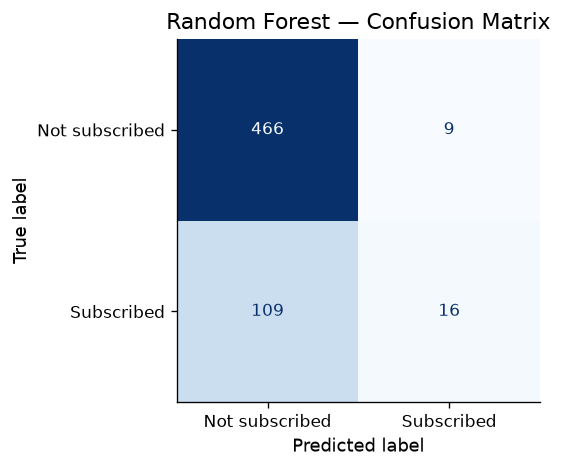

TN=466  FP=9  FN=109  TP=16


In [30]:
# YOUR CODE HERE
# Confusion matrix

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Not subscribed', 'Subscribed']
)
fig, ax = plt.subplots(figsize=(5, 4))
disp_rf.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"TN={cm_rf[0,0]}  FP={cm_rf[0,1]}  FN={cm_rf[1,0]}  TP={cm_rf[1,1]}")
#END[Sonnet]

In [31]:
# YOUR CODE HERE
# Classification report + ROC-AUC

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
print(classification_report(y_test, y_pred_rf,
                             target_names=['Not subscribed', 'Subscribed']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC: {auc_rf:.4f}")
#END[Sonnet]

                precision    recall  f1-score   support

Not subscribed       0.81      0.98      0.89       475
    Subscribed       0.64      0.13      0.21       125

      accuracy                           0.80       600
     macro avg       0.73      0.55      0.55       600
  weighted avg       0.77      0.80      0.75       600

ROC-AUC: 0.6460


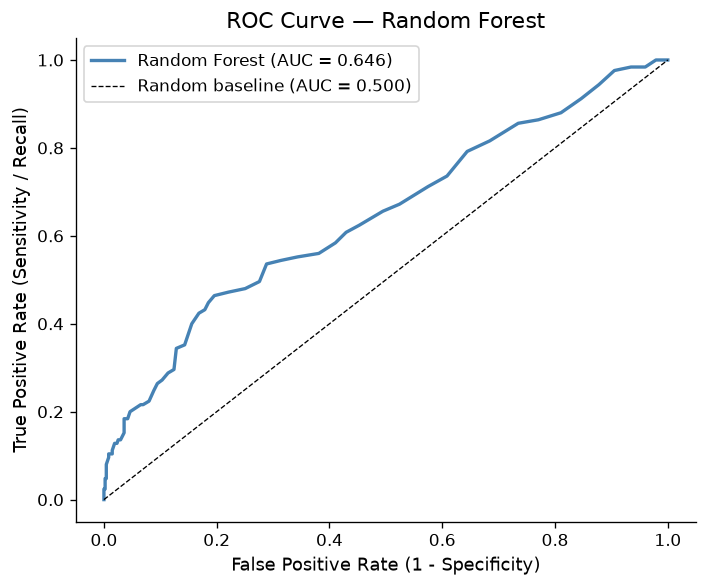

In [32]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rf, tpr_rf, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('ROC Curve — Random Forest')
ax.legend()
plt.tight_layout()
plt.show()
#END[Sonnet]

### C3 — Model Comparison


In [33]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
    ],
    'F1 (class 1)': [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
    ],
    'Precision (class 1)': [
        precision_score(y_test, y_pred_lr, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1),
    ],
    'Recall (class 1)': [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1),
    ],
})
metrics_df.set_index('Model').round(4)
#END[Sonnet]

,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.7374,0.2733,0.6111,0.176
Random Forest,0.6460,0.2133,0.6400,0.128


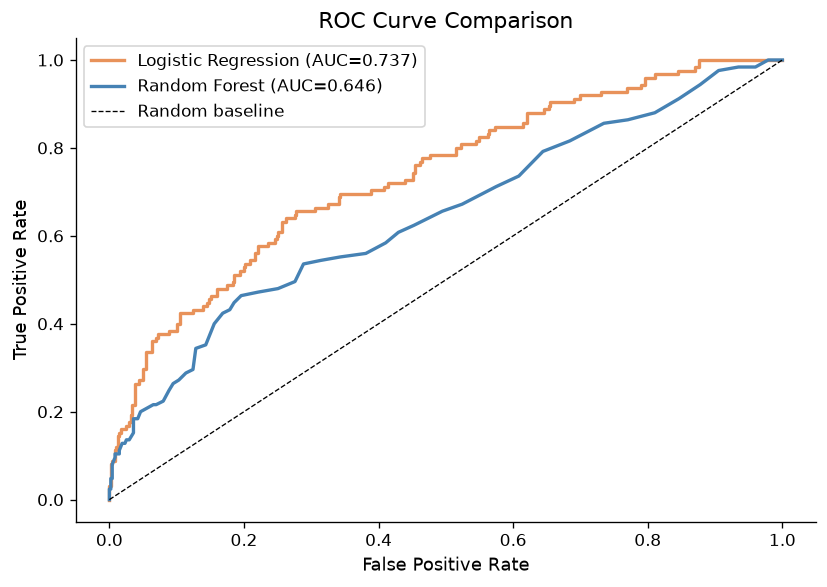

In [36]:
# YOUR CODE HERE
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much?*
- Logistic Regression shows ROC-AUC: 0.737. Random Forest shows ROC-AUC: 0.646. The higher value of logistic regression shows that there is more correlation. Logtistic regression also performed better in F1 (0.2733) and Recall (0.176) than Random Forest's F1 (0.2133) and Recall (0.128). Logistic Regression's Precision (0.6111) is lower than Random Forest's Precision (0.6400). Logistic Regerssion performed better.

*Explain why the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features).*
- I can see a difference in the results of each model because the features in relation to subscribers are mostly linear which is geared towards logistic regression and less for random forest. Logistic regression is ideal for this data. Random Forest provides no benefit because complex (not predictable) patterns do not exist here.

*If your model performed worse than logistic regression, that is a valid finding — explain why.*
- Yes, the Random Forest model underperformed. Simpler models often outperform complex ones when the underlying patterns are linear, the dataset is moderately sized, and the classes are imbalanced. Random Forest would be better with hyperparameter tuning (limiting tree depth, increasing minimum leaf size) or on a dataset with genuinely non linear feature interactions.

### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [35]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

#BEGIN[Sonnet][claude.ai][# BEGIN ... # END fill in the code for me.]
param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features':    ['sqrt', 'log2'],
}

# Run cross-validated search on the TRAINING SET ONLY
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,      # number of random combinations to try
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,      # use all available CPU cores
    random_state=42
)
search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")

y_pred_tuned = search.best_estimator_.predict(X_test)
y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
auc_tuned    = roc_auc_score(y_test, y_prob_tuned)

print(f"\nTuned test AUC:   {auc_tuned:.4f}")
print(f"Default test AUC: {auc_rf:.4f}")
delta = auc_tuned - auc_rf
meaningful = abs(delta) > 0.01
print(f"\nDid tuning meaningfully change performance? "
      f"{'Yes' if meaningful else 'No'} — AUC changed by {delta:+.4f}, "
      f"{'a meaningful gain' if meaningful else 'which is negligible'}.")
#END[Sonnet]


Best parameters: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}
Best CV AUC:     0.7327

Tuned test AUC:   0.7157
Default test AUC: 0.6460

Did tuning meaningfully change performance? Yes — AUC changed by +0.0697, a meaningful gain.


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
